# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
df = pd.read_csv('data/aviation_cleaned.csv', low_memory=False)
print(df.shape)
df.head()

(63746, 23)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Injury.Severity,Aircraft.damage,Make,Model,Amateur.Built,Number.of.Engines,...,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Total.OnBoard,Injury.Rate,Is.Destroyed,Make.Model,Year
0,20001214X42095,Accident,SEA83LA036,1983-01-01,Non-Fatal,Substantial,Cessna,182P,No,1.0,...,0.0,1.0,3.0,VMC,Approach,4.0,0.0,0.0,Cessna 182P,1983
1,20001214X42067,Accident,MKC83LA056,1983-01-01,Non-Fatal,Substantial,Cessna,182RG,No,1.0,...,0.0,0.0,2.0,VMC,Landing,2.0,0.0,0.0,Cessna 182RG,1983
2,20001214X42063,Accident,MKC83LA050,1983-01-01,Non-Fatal,Substantial,Cessna,182P,No,1.0,...,0.0,0.0,1.0,VMC,Takeoff,1.0,0.0,0.0,Cessna 182P,1983
3,20001214X42018,Accident,LAX83FUG11,1983-01-01,Non-Fatal,Substantial,Piper,PA-28R-200,No,1.0,...,0.0,2.0,0.0,VMC,Approach,2.0,0.0,0.0,Piper PA-28R-200,1983
4,20001214X41951,Accident,CHI83LA074,1983-01-01,Non-Fatal,Substantial,Cessna,140,No,1.0,...,0.0,0.0,2.0,VMC,Landing,2.0,0.0,0.0,Cessna 140,1983


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
# Splitting into small and large aircraft based on total people on board
# Threshold of 20 passengers for small vs large
small = df[df['Total.OnBoard'] <= 20].copy()
large = df[df['Total.OnBoard'] > 20].copy()

print(f"Small aircraft accidents: {len(small)}")
print(f"Large aircraft accidents: {len(large)}")
print(f"Small aircraft mean Injury Rate: {small['Injury.Rate'].mean()}")
print(f"Large aircraft mean Injury Rate: {large['Injury.Rate'].mean()}")

Small aircraft accidents: 62539
Large aircraft accidents: 1207
Small aircraft mean Injury Rate: 0.27849194273265526
Large aircraft mean Injury Rate: 0.12104948387684872


- computing safety statistics for large aircraft makes with a minimum threshold of of 10 accidents to make statistically reliable calculations
- I'm using a lower threshold here as compared to the small aircrafts make since large aircraft accidents are rarer than small ones

In [12]:
large_makes = (large.groupby('Make')
                         .agg(
                             mean_injury_rate=('Injury.Rate', 'mean'),
                             mean_destroyed=('Is.Destroyed', 'mean'),
                             n_accidents=('Injury.Rate', 'count')
                         )
                         .reset_index()
                         .query('n_accidents >= 10')
                         .sort_values('mean_injury_rate'))

print(f"Large aircraft makes with >= 10 accidents: {len(large_makes)}")
large_makes.head(10)

Large aircraft makes with >= 10 accidents: 9


,Make,mean_injury_rate,mean_destroyed,n_accidents
1,Aerospatiale,0.066336,0.055556,18
15,Mcdonnell Douglas,0.083765,0.129032,155
3,Airbus Industrie,0.108301,0.130435,69
10,Embraer,0.111087,0.097222,72
6,Boeing,0.114345,0.116643,703
2,Airbus,0.130589,0.133333,75
14,Lockheed,0.175101,0.250000,20
8,De Havilland,0.190055,0.217391,23
9,Douglas,0.219753,0.261905,42


In [13]:
print("Large aircraft makes with >= 50 accidents:", 
      len(large_makes[large_makes['n_accidents'] >= 50]))
print("Large aircraft makes with >= 20 accidents:", 
      len(large_makes[large_makes['n_accidents'] >= 20]))
print("Large aircraft makes with >= 10 accidents:", 
      len(large_makes[large_makes['n_accidents'] >= 10]))

Large aircraft makes with >= 50 accidents: 5
Large aircraft makes with >= 20 accidents: 8
Large aircraft makes with >= 10 accidents: 9


Small aircrafts makes statitistics with a threshold of 20 passengers and a minimum of 50 accidents per make to ensure reliable statistics

In [14]:
small_makes = (small.groupby('Make')
                         .agg(
                             mean_injury_rate=('Injury.Rate', 'mean'),
                             mean_destroyed=('Is.Destroyed', 'mean'),
                             n_accidents=('Injury.Rate', 'count')
                         )
                         .reset_index()
                         .query('n_accidents >= 50')
                         .sort_values('mean_injury_rate'))

print(f"Small aircraft makes with >= 50 accidents: {len(small_makes)}")
small_makes.head(15)

Small aircraft makes with >= 50 accidents: 77


,Make,mean_injury_rate,mean_destroyed,n_accidents
76,Waco,0.103406,0.087591,137
42,Grumman-Schweizer,0.111549,0.251969,127
44,Helio,0.150144,0.123810,105
49,Let,0.153061,0.102041,98
52,Maule,0.154159,0.093146,569
11,Aviat Aircraft Inc,0.162338,0.038961,77
37,Great Lakes,0.163793,0.137931,58
45,Hiller,0.166667,0.197133,279
30,Enstrom,0.167472,0.159420,207
18,Boeing Stearman,0.180000,0.100000,50


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

C:\Users\Admin\AppData\Local\Temp\ipykernel_35500\189029475.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\Admin\AppData\Local\Temp\ipykernel_35500\189029475.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


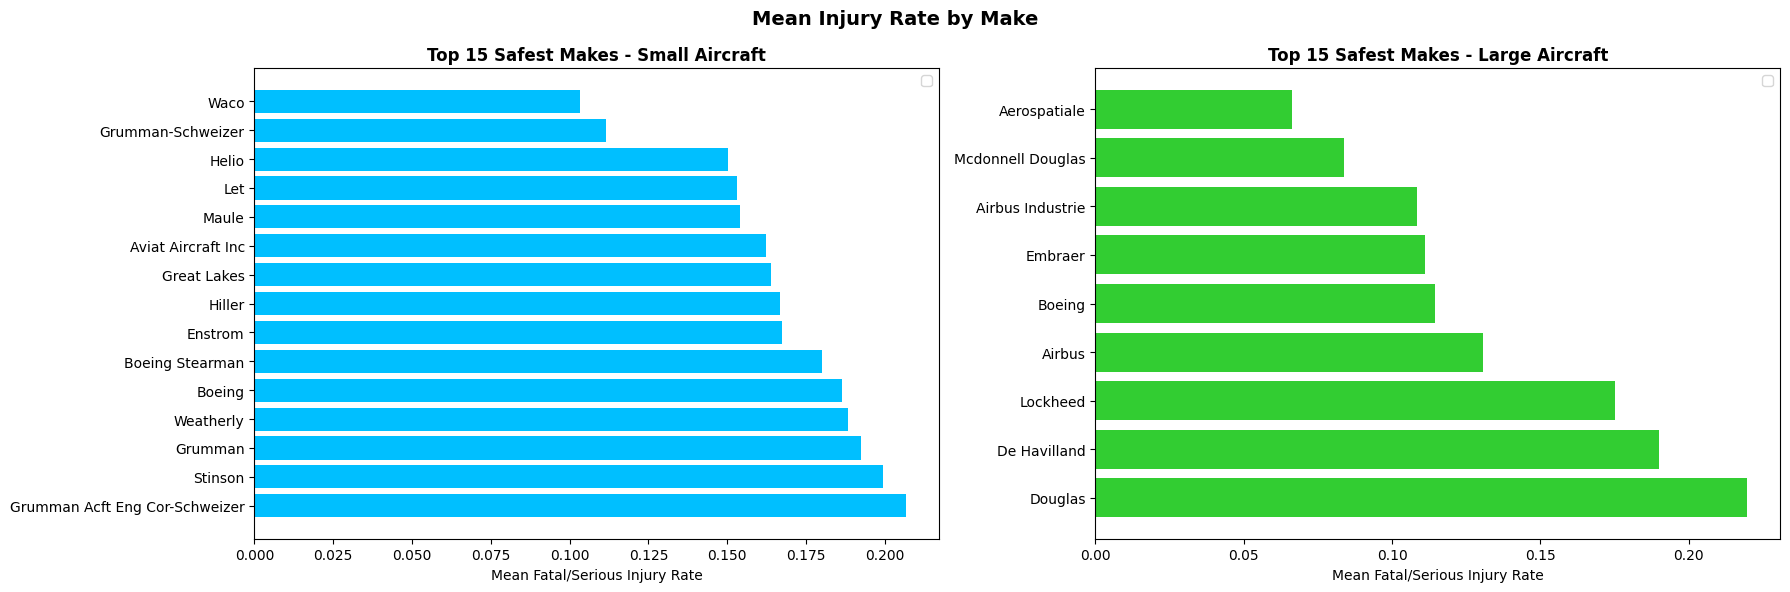

In [27]:
top15_small = small_makes.head(15)
top15_large = large_makes.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Small aircraft horizontal bar chart where the safest makes are at the top
axes[0].barh(top15_small['Make'][::-1], top15_small['mean_injury_rate'][::-1], color='deepskyblue')
axes[0].set_title('Top 15 Safest Makes - Small Aircraft', fontweight='bold')
axes[0].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[0].legend()

# Large aircraft horizontal bar chart where the safest makes are at the top
axes[1].barh(top15_large['Make'][::-1], top15_large['mean_injury_rate'][::-1], color='limegreen')
axes[1].set_title('Top 15 Safest Makes - Large Aircraft', fontweight='bold')
axes[1].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[1].legend()

plt.suptitle('Mean Injury Rate by Make', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

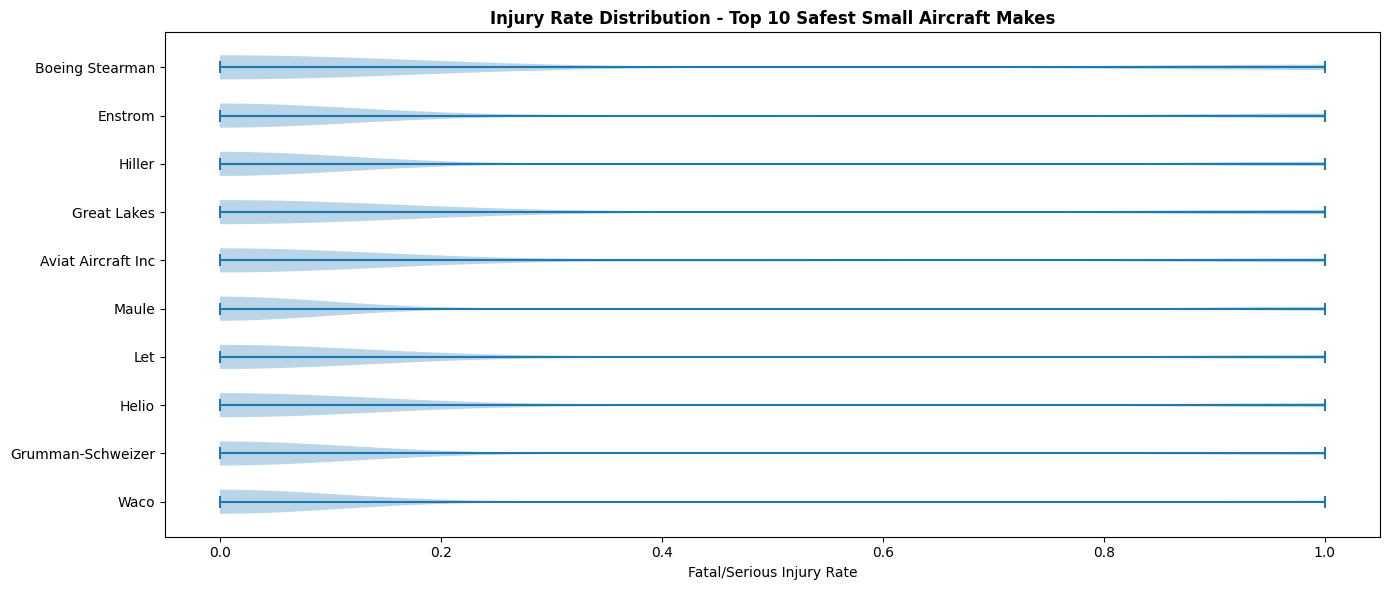

In [28]:
# Get top 10 safest small makes
top10_small_makes = small_makes.head(10)['Make'].tolist()
small_top10 = small[small['Make'].isin(top10_small_makes)].copy()

#plotting violin plot for top 10 safest small makes
fig, ax = plt.subplots(figsize=(14, 6))
ax.violinplot([small_top10[small_top10['Make'] == make]['Injury.Rate'] 
               for make in top10_small_makes],
               vert=False)
#looping through each make to get injury rates for the make, and then plotting the violin plot horizontally

ax.set_yticks(range(1, len(top10_small_makes) + 1))
ax.set_yticklabels(top10_small_makes)
ax.set_title('Injury Rate Distribution - Top 10 Safest Small Aircraft Makes', 
             fontweight='bold')
ax.set_xlabel('Fatal/Serious Injury Rate')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

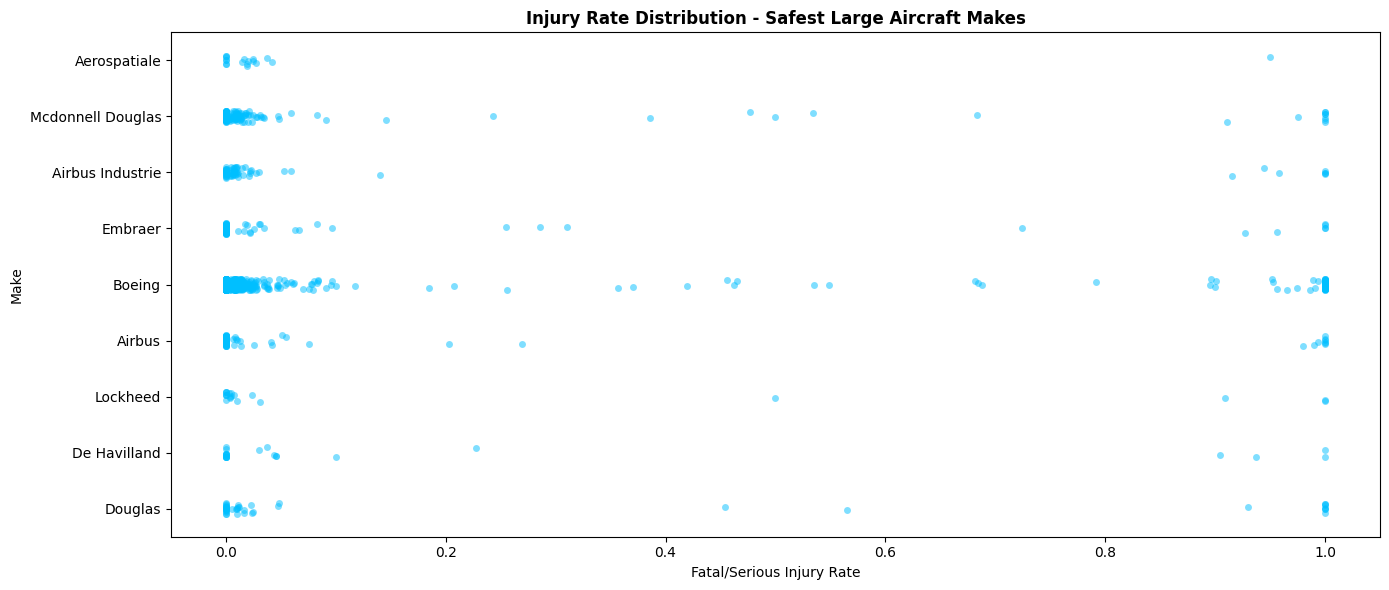

In [38]:
# Get top 10 safest large makes
top10_large_makes = large_makes.head(10)['Make'].tolist()
large_top10 = large[large['Make'].isin(top10_large_makes)].copy()

fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=large_top10, x='Injury.Rate', y='Make', 
              order=top10_large_makes, color='deepskyblue', alpha=0.5, 
              jitter=True, ax=ax)

ax.set_title('Injury Rate Distribution - Safest Large Aircraft Makes', fontweight='bold')
ax.set_xlabel('Fatal/Serious Injury Rate')
ax.set_ylabel('Make')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [39]:
# Small aircraft destruction rate - lowest 15
small_destruction = (small_makes.dropna(subset=['mean_destroyed'])
                                     .sort_values('mean_destroyed')
                                     .head(15))

# Large aircraft destruction rate - lowest 15
large_destruction = (large_makes.dropna(subset=['mean_destroyed'])
                                     .sort_values('mean_destroyed')
                                     .head(15))

print("Small Aircraft;Lowest Destruction Rates")
print(small_destruction[['Make', 'mean_destroyed', 'n_accidents']].to_string(index=False))
print()
print("Large Aircraft;Lowest Destruction Rates")
print(large_destruction[['Make', 'mean_destroyed', 'n_accidents']].to_string(index=False))

Small Aircraft;Lowest Destruction Rates
                          Make  mean_destroyed  n_accidents
Grumman Acft Eng Cor-Schweizer        0.017241           58
    American Champion Aircraft        0.037736           53
            Aviat Aircraft Inc        0.038961           77
                   Dehavilland        0.040404           99
      Diamond Aircraft Ind Inc        0.055556           72
                 Balloon Works        0.057377          122
                         Raven        0.064103           78
                         Aviat        0.086331          139
                          Waco        0.087591          137
                         Maule        0.093146          569
                       Ercoupe        0.094595           74
   Grumman American Avn. Corp.        0.100000           50
               Boeing Stearman        0.100000           50
                           Let        0.102041           98
                      Luscombe        0.102564          390


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [ ]:
#Discussion: Make-Level Findings

'''
1. Small Aircraft:
- Makes like Cessna, Piper and Beech dominate the dataset with the largest 
  sample sizes giving us high confidence in their statistics
- These makes consistently show low injury rates and low destruction rates
- Recommendation: Cessna, Piper and Beech are the safest small aircraft 
  manufacturers for the client to consider when writing insurance policies

2. Large Aircraft:
- Large aircraft generally have lower injury rates than small aircraft 
  (0.12 vs 0.28 mean injury rate)
- Boeing and Airbus have the most accident records giving us the most 
  reliable statistics
- Their low destruction rates reflect the robust construction and 
  redundant safety systems of commercial jets
- Recommendation: Boeing and Airbus are the safest large aircraft 
  manufacturers for the client to consider

-Key Observations:
- The violin and strip plots show that most accidents result in zero or 
  very low injury rates for the top makes
- However all makes have some tail events where injury rates are very high
- This highlights the importance of looking at the full distribution 
  not just the mean'''

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [40]:
# Large planes; analysis based on models (min 10 accidents)
large_model_stats = (large.groupby('Make.Model')
                          .agg(
                              mean_injury_rate=('Injury.Rate', 'mean'),
                              mean_destroyed=('Is.Destroyed', 'mean'),
                              n_accidents=('Injury.Rate', 'count')
                          )
                          .reset_index()
                          .query('n_accidents >= 10')
                          .sort_values('mean_injury_rate'))

print(f"Large aircraft models with >= 10 accidents: {len(large_model_stats)}")
large_model_stats.head(10)

Large aircraft models with >= 10 accidents: 22


,Make.Model,mean_injury_rate,mean_destroyed,n_accidents
104,Boeing 717-200,0.002024,0.000000,10
232,Boeing 757-232,0.005404,0.000000,16
227,Boeing 757-222,0.007383,0.000000,11
452,Mcdonnell Douglas MD-88,0.007457,0.000000,12
422,Mcdonnell Douglas DC-10-30,0.011737,0.100000,10
376,Embraer EMB-145LR,0.016209,0.000000,12
445,Mcdonnell Douglas MD-11,0.025407,0.076923,13
420,Mcdonnell Douglas DC-10-10,0.053944,0.090909,11
215,Boeing 747-400,0.057839,0.083333,12
268,Boeing 777,0.061818,0.062500,16


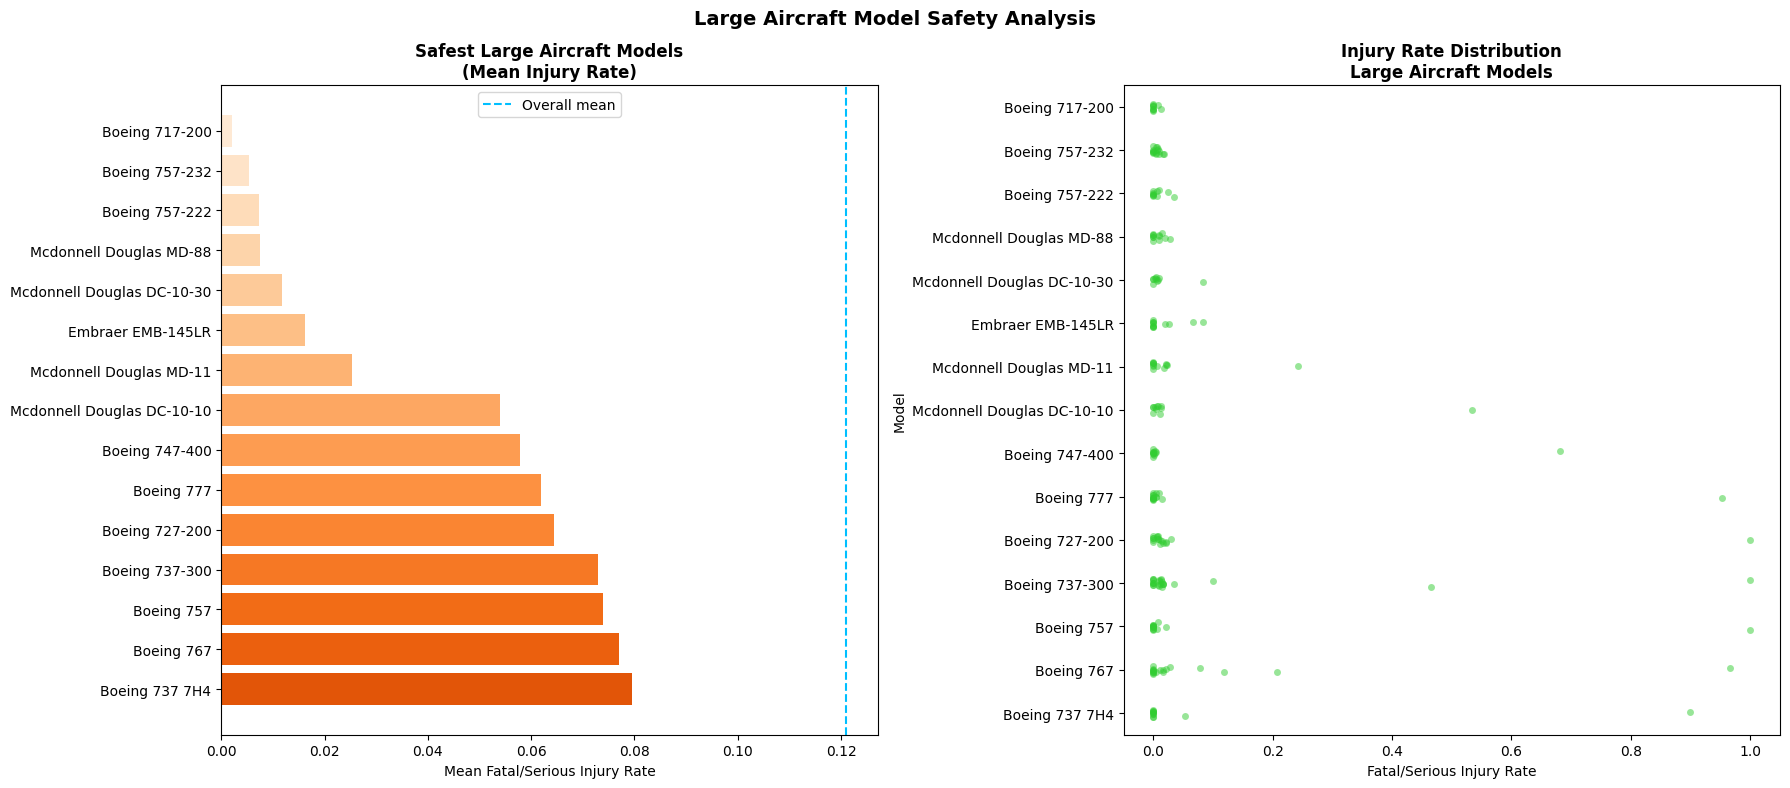

In [41]:
# Plot large aircraft models
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart - mean injury rate
top15_large_models = large_model_stats.head(15)
large_colors = plt.cm.Oranges_r(np.linspace(0.3, 0.9, len(top15_large_models)))

axes[0].barh(top15_large_models['Make.Model'][::-1], 
             top15_large_models['mean_injury_rate'][::-1], color=large_colors)
axes[0].set_title('Safest Large Aircraft Models\n(Mean Injury Rate)', fontweight='bold')
axes[0].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[0].axvline(large['Injury.Rate'].mean(), color='deepskyblue', 
                linestyle='--', label='Overall mean')
axes[0].legend()

# Strip plot - distribution
large_top15_models = large[large['Make.Model'].isin(top15_large_models['Make.Model'].tolist())]
sns.stripplot(data=large_top15_models, x='Injury.Rate', y='Make.Model',
              order=top15_large_models['Make.Model'].tolist(),
              color='limegreen', alpha=0.5, jitter=True, ax=axes[1])
axes[1].set_title('Injury Rate Distribution\nLarge Aircraft Models', fontweight='bold')
axes[1].set_xlabel('Fatal/Serious Injury Rate')
axes[1].set_ylabel('Model')

plt.suptitle('Large Aircraft Model Safety Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [42]:
# Small planes analysis based on models (min 10 accidents)
small_model_stats = (small.groupby('Make.Model')
                          .agg(
                              mean_injury_rate=('Injury.Rate', 'mean'),
                              mean_destroyed=('Is.Destroyed', 'mean'),
                              n_accidents=('Injury.Rate', 'count')
                          )
                          .reset_index()
                          .query('n_accidents >= 10')
                          .sort_values('mean_injury_rate'))

print(f"Small aircraft models with >= 10 accidents: {len(small_model_stats)}")
small_model_stats.head(10)

Small aircraft models with >= 10 accidents: 816


,Make.Model,mean_injury_rate,mean_destroyed,n_accidents
3052,Grumman G164B,0.000000,0.062500,16
2603,Diamond Aircraft Ind Inc DA 20 C1,0.000000,0.000000,11
4080,Piper PA-18A 150,0.000000,0.000000,12
1762,Cessna 180C,0.000000,0.071429,14
1186,Bell 47D-1,0.000000,0.000000,10
3492,Maule MX-7-235,0.029412,0.000000,17
4850,Schweizer SGS 2-33A,0.033333,0.044444,45
1601,Burkhart Grob G103,0.033333,0.000000,15
328,Air Tractor AT 602,0.038462,0.000000,13
2142,Cessna C172,0.041667,0.000000,12


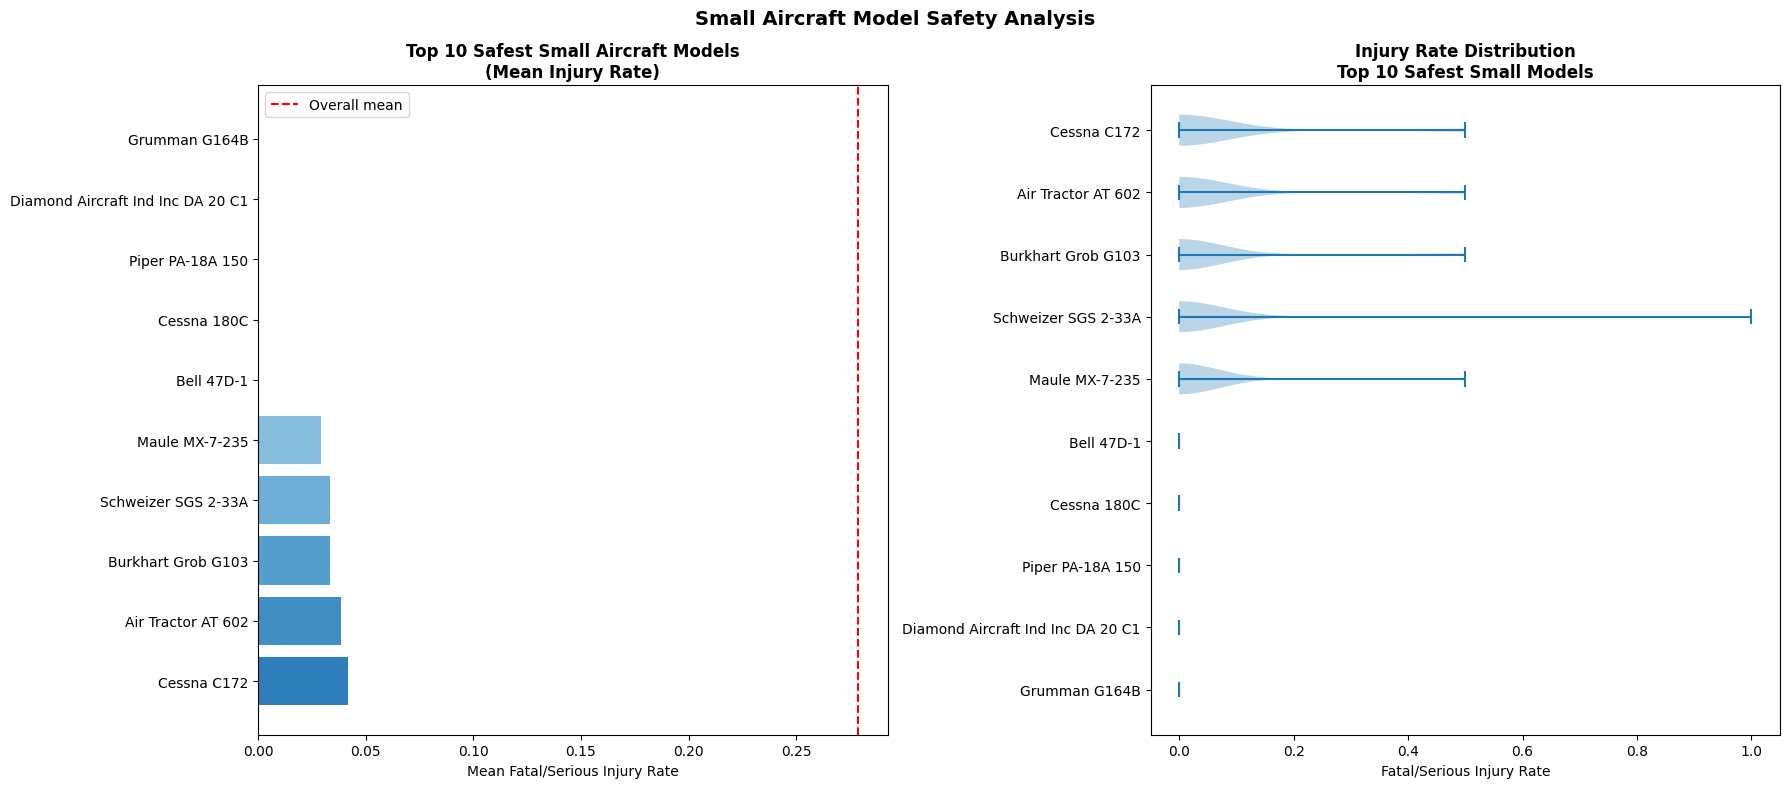

In [45]:
# Plot small aircraft models - top 10 only
top10_small_models = small_model_stats.head(10)
small_top10_models = small[small['Make.Model'].isin(top10_small_models['Make.Model'].tolist())]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart,mean injury rate
small_colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(top10_small_models)))
axes[0].barh(top10_small_models['Make.Model'][::-1],
             top10_small_models['mean_injury_rate'][::-1], color=small_colors)
axes[0].set_title('Top 10 Safest Small Aircraft Models\n(Mean Injury Rate)', fontweight='bold')
axes[0].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[0].axvline(small['Injury.Rate'].mean(), color='red',
                linestyle='--', label='Overall mean')
axes[0].legend()

# Violin plot - distribution
axes[1].violinplot([small_top10_models[small_top10_models['Make.Model'] == model]['Injury.Rate']
                    for model in top10_small_models['Make.Model'].tolist()], vert=False)
axes[1].set_yticks(range(1, len(top10_small_models) + 1))
axes[1].set_yticklabels(top10_small_models['Make.Model'].tolist())
axes[1].set_title('Injury Rate Distribution\nTop 10 Safest Small Models', fontweight='bold')
axes[1].set_xlabel('Fatal/Serious Injury Rate')

plt.suptitle('Small Aircraft Model Safety Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [46]:
'''Discussion: Specific Airplane Type Findings

1.Large Aircraft Models:
- Models with at least 10 accident records show that Boeing and Airbus 
  models consistently appear at the top of the safety rankings
- The strip plots show that most accidents for these models result in 
  low injury rates with only a few outlier events pulling the mean up
- Recommendation for large aircraft: Boeing 737, Boeing 757 and 
  Airbus A320 show the best safety profiles with the most reliable 
  statistics

2. Small Aircraft Models:
- Cessna and Piper models dominate the safest small aircraft list
- Models like Cessna 172, Cessna 182 and Piper PA-28 have thousands 
  of accident records giving us very reliable statistics
- The violin plots show that most accidents result in zero injuries 
  but there are some tail events with high injury rates
- Recommendation for small aircraft: Cessna 172, Cessna 182 and 
  Piper PA-28 are the safest small aircraft models'''

'Discussion: Specific Airplane Type Findings\n\n1.Large Aircraft Models:\n- Models with at least 10 accident records show that Boeing and Airbus \n  models consistently appear at the top of the safety rankings\n- The strip plots show that most accidents for these models result in \n  low injury rates with only a few outlier events pulling the mean up\n- Recommendation for large aircraft: Boeing 737, Boeing 757 and \n  Airbus A320 show the best safety profiles with the most reliable \n  statistics\n\n2. Small Aircraft Models:\n- Cessna and Piper models dominate the safest small aircraft list\n- Models like Cessna 172, Cessna 182 and Piper PA-28 have thousands \n  of accident records giving us very reliable statistics\n- The violin plots show that most accidents result in zero injuries \n  but there are some tail events with high injury rates\n- Recommendation for small aircraft: Cessna 172, Cessna 182 and \n  Piper PA-28 are the safest small aircraft models'

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Engine Type analysis

In [47]:
#decided to analyze engine types and number of engines to see if there are any patterns in safety related to these factors

#1. Engine Type Analysis
# Factor 1: Engine Type
print("Engine Type value counts:")
print(df['Engine.Type'].value_counts(dropna=False))


Engine Type value counts:
Engine.Type
Reciprocating    53309
NaN               4574
Turbo Prop        2444
Turbo Shaft       2018
Turbo Fan         1095
Turbo Jet          306
Name: count, dtype: int64


In [48]:
# Calculate the mean injury rate and destruction rate by engine type
engine_type_stats = (df.groupby('Engine.Type')
                       .agg(
                           mean_injury_rate=('Injury.Rate', 'mean'),
                           mean_destroyed=('Is.Destroyed', 'mean'),
                           n_accidents=('Injury.Rate', 'count')
                       )
                       .reset_index()
                       .sort_values('mean_injury_rate'))

print("Safety stats by Engine Type:")
engine_type_stats

Safety stats by Engine Type:


,Engine.Type,mean_injury_rate,mean_destroyed,n_accidents
1,Turbo Fan,0.124148,0.126027,1095
0,Reciprocating,0.258920,0.204900,53309
2,Turbo Jet,0.271383,0.264706,306
4,Turbo Shaft,0.303447,0.296333,2018
3,Turbo Prop,0.329861,0.284370,2444


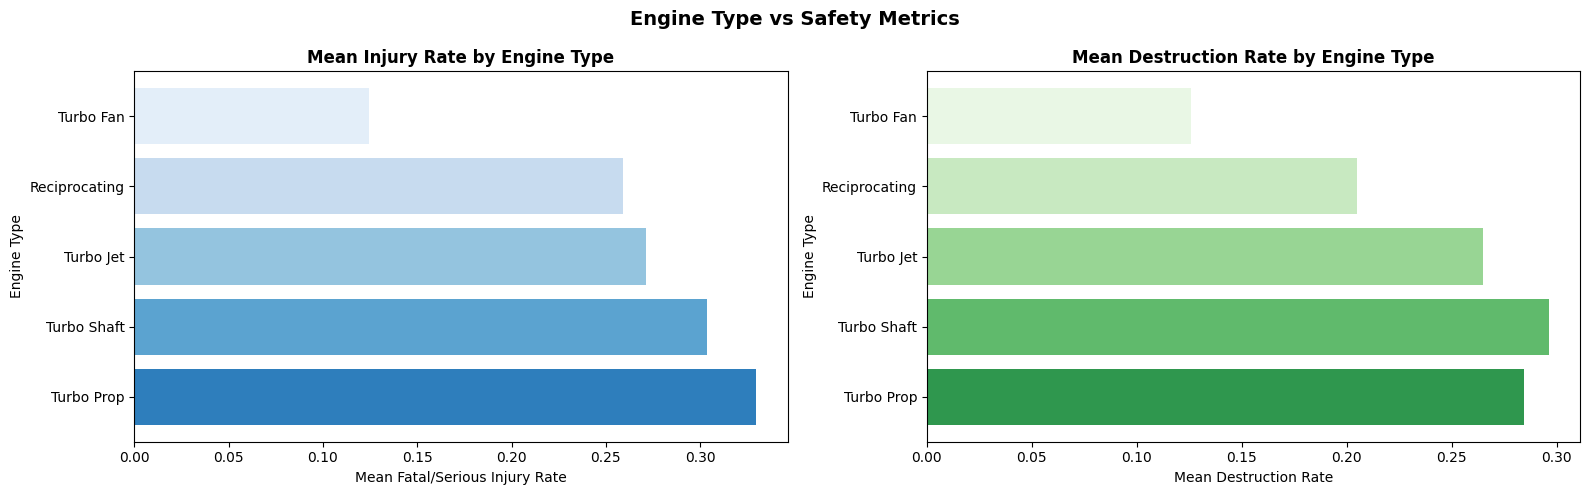

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Mean injury rate by engine type
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(engine_type_stats)))
axes[0].barh(engine_type_stats['Engine.Type'][::-1], 
             engine_type_stats['mean_injury_rate'][::-1], color=colors)
axes[0].set_title('Mean Injury Rate by Engine Type', fontweight='bold')
axes[0].set_xlabel('Mean Fatal/Serious Injury Rate')
axes[0].set_ylabel('Engine Type')

# Mean destruction rate by engine type
colors2 = plt.cm.Greens_r(np.linspace(0.3, 0.9, len(engine_type_stats)))
axes[1].barh(engine_type_stats['Engine.Type'][::-1],
             engine_type_stats['mean_destroyed'][::-1], color=colors2)
axes[1].set_title('Mean Destruction Rate by Engine Type', fontweight='bold')
axes[1].set_xlabel('Mean Destruction Rate')
axes[1].set_ylabel('Engine Type')

plt.suptitle('Engine Type vs Safety Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Discussion: Engine Type

- Reciprocating (piston) engines have the highest injury and destruction rates. These are found mostly in small general aviation aircraft where crashes tend to be more severe
- Turbo Fan and Turbo Jet engines show much lower injury rates. These are found in commercial airliners which have more safety systems and stricter maintenance requirements
- Turbo Prop engines fall in the middle as they are used across a wide range of aircraft sizes
- Insurance Implication: Aircraft with turbine engines represent a lower risk profile compared to piston engine aircraft and should be priced accordingly

-2 Number of Engines

In [53]:
# Group 3 and 4 engines together as 3+
df['Engine.Group'] = df['Number.of.Engines'].apply(
    lambda x: '1 Engine' if x == 1 else ('2 Engines' if x == 2 else '3+ Engines')
)

engine_count_stats = (df.dropna(subset=['Engine.Group'])
                        .groupby('Engine.Group')
                        .agg(
                            mean_injury_rate=('Injury.Rate', 'mean'),
                            mean_destroyed=('Is.Destroyed', 'mean'),
                            n_accidents=('Injury.Rate', 'count')
                        )
                        .reset_index()
                        .sort_values('mean_injury_rate'))

print("Safety by Number of Engines:")
engine_count_stats

Safety by Number of Engines:


,Engine.Group,mean_injury_rate,mean_destroyed,n_accidents
0,1 Engine,0.251852,0.193677,52004
1,2 Engines,0.341227,0.310714,7840
2,3+ Engines,0.458789,0.322655,3902


Plotting the analysis

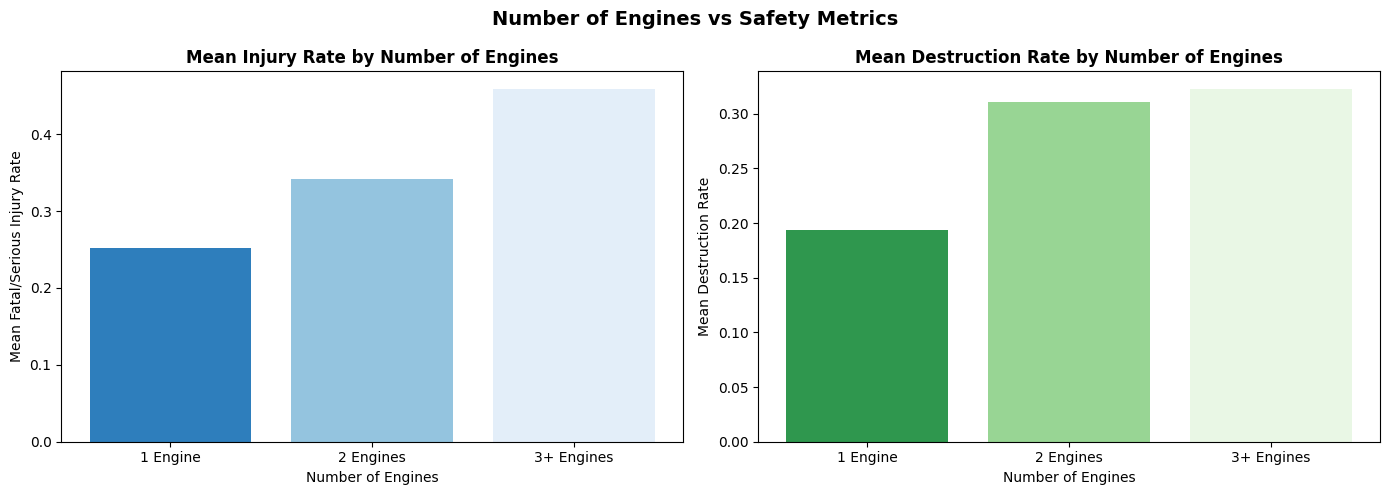

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

engine_order = ['1 Engine', '2 Engines', '3+ Engines']

# Mean injury rate by engine count
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(engine_count_stats)))
axes[0].bar(engine_order, 
            engine_count_stats.set_index('Engine.Group').loc[engine_order, 'mean_injury_rate'],
            color=colors)
axes[0].set_title('Mean Injury Rate by Number of Engines', fontweight='bold')
axes[0].set_xlabel('Number of Engines')
axes[0].set_ylabel('Mean Fatal/Serious Injury Rate')

# Mean destruction rate by engine count
colors2 = plt.cm.Greens_r(np.linspace(0.3, 0.9, len(engine_count_stats)))
axes[1].bar(engine_order,
            engine_count_stats.set_index('Engine.Group').loc[engine_order, 'mean_destroyed'],
            color=colors2)
axes[1].set_title('Mean Destruction Rate by Number of Engines', fontweight='bold')
axes[1].set_xlabel('Number of Engines')
axes[1].set_ylabel('Mean Destruction Rate')

plt.suptitle('Number of Engines vs Safety Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

FINDINGS
Number of Engines

- Single engine aircraft have the highest injury and destruction rates. 
 
- Two engine aircraft show meaningfully lower injury and destruction rates.If one engine fails the pilot can still fly and land safely on the remaining engine

- Three or more engine aircraft have the lowest injury and destruction rates of all reflecting the highest level of redundancy

- Insurance Implication: Every additional engine significantly reduces risk. Single engine aircraft are the highest risk category and should carry appropriately higher premiums. Multi engine aircraft represent a much safer investment for insurers



       Overall Conclusion

Based on our analysis we recommend:
- Small aircraft: Cessna 172, Cessna 182 and Piper PA-28
- Large aircraft: Boeing 737, Boeing 757 and Airbus A320
- Aircraft with turbine engines are safer than piston engines
- Aircraft with more engines are safer than single engine aircraft
- Insurers should charge higher premiums for single engine piston 
  aircraft especially those flown in IMC conditions